# 01 — Je data voorbereiden

Deze notebook is de uitvoerbare versie van [`docs/je-data-voorbereiden.md`](../docs/je-data-voorbereiden.md)
en [`docs/validatie.md`](../docs/validatie.md). We:

1. Laden de demodata en lopen het schema door
2. Genereren een **validatierapport** dat je 1-op-1 op je eigen data kunt draaien
3. Visualiseren een typische aanmeldcurve over meerdere jaren
4. Maken een dekkings-heatmap die ontbrekende weken zichtbaar maakt

> 💡 **Voor je eigen data:** vervang `data/input/vooraanmeldingen_cumulatief.csv` door je
> eigen ETL-output en herstart de kernel. De validatie-cellen werken zonder code-aanpassing.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


## 1. Data laden

`load_cumulative()` laadt de cumulatieve telregels, de historische realisatie én de
RAW-vorm (zonder preprocessing) in één call. De preprocessing past dezelfde renames
toe als de pipeline-strategie — als analist hoef je dat niet zelf te doen.


In [2]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


## 2. Schema van het cumulatieve bestand

Eén rij = één combinatie van (jaar × week × opleiding × herkomst × examentype). De
twee belangrijkste numerieke velden zijn `Gewogen vooraanmelders` en `Inschrijvingen`.


In [3]:
print("Kolommen + type:")
for col in data_cumulative.columns:
    print(f"  - {col:42s} {data_cumulative[col].dtype}")
data_cumulative.head(3)


Kolommen + type:
  - Korte naam instelling                      str
  - Collegejaar                                int32
  - Weeknummer rapportage                      int64
  - Weeknummer                                 int32
  - Faculteit                                  str
  - Examentype                                 str
  - Croho groepeernaam                         str
  - Naam Croho opleiding Nederlands            str
  - Croho                                      int64
  - Herinschrijving                            str
  - Hogerejaars                                str
  - Herkomst                                   str
  - Gewogen vooraanmelders                     float64
  - Ongewogen vooraanmelders                   float64
  - Aantal aanmelders met 1 aanmelding         float64
  - Inschrijvingen                             float64
  - ts                                         float64


,Korte naam instelling,Collegejaar,Weeknummer rapportage,Weeknummer,Faculteit,Examentype,Croho groepeernaam,Naam Croho opleiding Nederlands,Croho,Herinschrijving,Hogerejaars,Herkomst,Gewogen vooraanmelders,Ongewogen vooraanmelders,Aantal aanmelders met 1 aanmelding,Inschrijvingen,ts
0,21PB,2016,1,1,SOW,Bachelor,B Psychologie,B Psychologie,56604,Nee,Nee,EER,2.33,3.0,NaN,NaN,2.33
1,21PB,2016,1,1,SOW,Bachelor,B Psychologie,B Psychologie,56604,Nee,Nee,Niet-EER,1.55,2.0,NaN,NaN,1.55
2,21PB,2016,1,1,MED,Bachelor,B Geneeskunde,B Geneeskunde,56551,Nee,Nee,NL,22.48,29.0,NaN,NaN,22.48


## 3. Validatierapport

Hieronder een **draaibaar rapport** dat de belangrijkste checks uit `docs/validatie.md`
direct op de geladen data uitvoert. Op eigen data laat dit in één klap zien of je klaar
bent om te draaien.


In [4]:
def validatie_rapport(df: pd.DataFrame, df_sc: pd.DataFrame) -> pd.DataFrame:
    """Compacte versie van de validatiechecks uit docs/validatie.md."""
    rows = []

    # 1. Verplichte kolommen
    verplicht = {"Collegejaar", "Weeknummer", "Croho groepeernaam",
                 "Herkomst", "Examentype", "Gewogen vooraanmelders", "Inschrijvingen"}
    ontbreekt = verplicht - set(df.columns)
    rows.append({
        "Check": "Verplichte kolommen aanwezig",
        "Status": "✅" if not ontbreekt else "❌",
        "Detail": "alle aanwezig" if not ontbreekt else f"ontbreken: {sorted(ontbreekt)}",
    })

    # 2. Jaarbereik (current_year - 15 .. current_year + 2 → soft error)
    jaren = sorted(df["Collegejaar"].dropna().unique().astype(int))
    huidig = 2024
    out_of_range = [y for y in jaren if y < huidig - 15 or y > huidig + 2]
    rows.append({
        "Check": "Collegejaar in plausibel bereik",
        "Status": "✅" if not out_of_range else "⚠️",
        "Detail": f"jaren {jaren[0]}–{jaren[-1]}" + (f" ; buiten bereik: {out_of_range}" if out_of_range else ""),
    })

    # 3. Herkomst-waarden
    herk = sorted(df["Herkomst"].dropna().unique())
    verwacht = {"NL", "EER", "Niet-EER"}
    onbekend = set(herk) - verwacht
    rows.append({
        "Check": "Herkomst-waarden geldig",
        "Status": "✅" if not onbekend else "⚠️",
        "Detail": f"{herk}" + (f" ; onbekend: {sorted(onbekend)}" if onbekend else ""),
    })

    # 4. NaN-percentage (warning > 5%, soft-error > 30%)
    nan_pct = df["Gewogen vooraanmelders"].isna().mean() * 100
    status = "✅" if nan_pct <= 5 else ("⚠️" if nan_pct <= 30 else "❌")
    rows.append({
        "Check": "Ontbrekende waarden in Gewogen vooraanmelders",
        "Status": status,
        "Detail": f"{nan_pct:.2f}% NaN",
    })

    # 5. Decimaalintegriteit (geen komma-strings of niet-numeriek) — FULL check, geen sample
    raw_col = df["Gewogen vooraanmelders"]
    if pd.api.types.is_numeric_dtype(raw_col):
        rows.append({
            "Check": "Decimaalintegriteit",
            "Status": "✅",
            "Detail": "kolom is numeriek (geen komma-strings)",
        })
    else:
        n_comma = raw_col.astype(str).str.contains(",", na=False).sum()
        rows.append({
            "Check": "Decimaalintegriteit",
            "Status": "❌" if n_comma > 0 else "⚠️",
            "Detail": f"{n_comma} rijen met komma; verwacht 0",
        })

    # 6. Gaten tussen weken (warning bij gat > 2 binnen één jaar)
    grootste_gat = 0
    for (_, jaar), grp in df.groupby(["Croho groepeernaam", "Collegejaar"]):
        weken = sorted(grp["Weeknummer"].unique())
        if len(weken) > 1:
            gaten = [b - a for a, b in zip(weken, weken[1:])]
            grootste_gat = max(grootste_gat, max(gaten))
    rows.append({
        "Check": "Geen grote gaten tussen weken",
        "Status": "✅" if grootste_gat <= 2 else "⚠️",
        "Detail": f"grootste gap = {grootste_gat} weken (warning bij > 2)",
    })

    # 7. Realisatie aansluit op aanmelddata?
    jaren_cum = set(df["Collegejaar"].astype(int))
    jaren_sc = set(df_sc["Collegejaar"].astype(int))
    gemeenschappelijk = jaren_cum & jaren_sc
    rows.append({
        "Check": "Realisatie (DUO) aanwezig voor aanmeldjaren",
        "Status": "✅" if len(gemeenschappelijk) >= 3 else "⚠️",
        "Detail": f"{len(gemeenschappelijk)} jaren overlappen (≥ 3 nodig voor ratio-model)",
    })

    return pd.DataFrame(rows)


rapport = validatie_rapport(data_cumulative, data_studentcount)
rapport


,Check,Status,Detail
0,Verplichte kolommen aanwezig,✅,alle aanwezig
1,Collegejaar in plausibel bereik,✅,jaren 2016–2024
2,Herkomst-waarden geldig,✅,"['EER', 'NL', 'Niet-EER']"
3,Ontbrekende waarden in Gewogen vooraanmelders,✅,0.00% NaN
4,Decimaalintegriteit,✅,kolom is numeriek (geen komma-strings)
5,Geen grote gaten tussen weken,✅,grootste gap = 1 weken (warning bij > 2)
6,Realisatie (DUO) aanwezig voor aanmeldjaren,✅,8 jaren overlappen (≥ 3 nodig voor ratio-model)


## 4. Visualisatie: jaarlijkse aanmeldcurve

Het seizoenspatroon dat SARIMA later gebruikt: rust in de zomer (weken 39–52),
steile stijging vanaf januari, knik rond 1 mei-deadline. Voor `B Bedrijfskunde`
(NL Bachelor) — een opleiding die op zowel HBO als WO bestaat — :


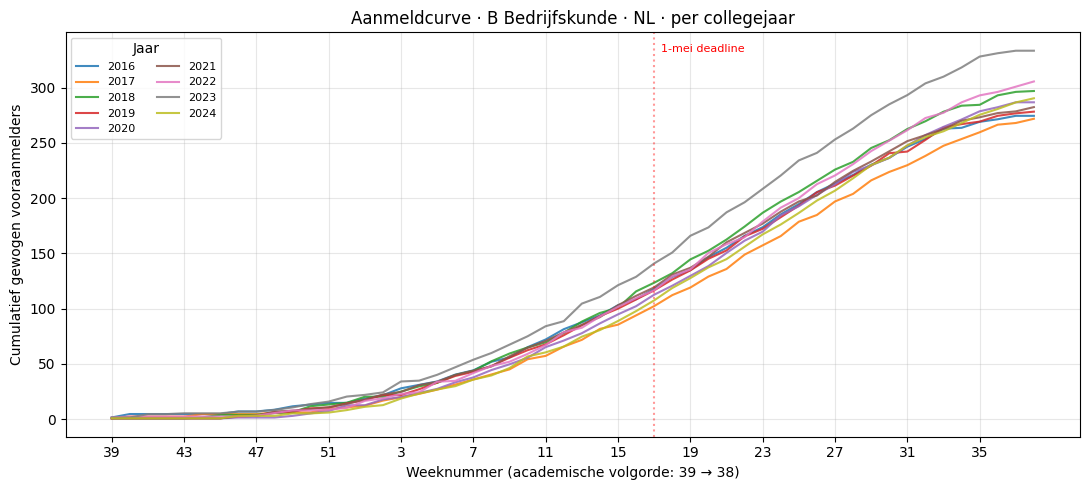

In [5]:
from studentprognose.utils.weeks import get_all_weeks_valid
from studentprognose.data.transforms import transform_data

PROGRAMMA = "B Bedrijfskunde"
HERKOMST = "NL"

wide = transform_data(data_cumulative.drop_duplicates(), "Gewogen vooraanmelders")
sample = wide[
    (wide["Croho groepeernaam"] == PROGRAMMA)
    & (wide["Herkomst"] == HERKOMST)
    & (wide["Examentype"] == "Bachelor")
].copy()
weekcols = get_all_weeks_valid(sample.columns)

fig, ax = plt.subplots(figsize=(11, 5))
for jaar in sorted(sample["Collegejaar"].unique()):
    row = sample[sample["Collegejaar"] == jaar][weekcols].iloc[0]
    ax.plot(range(len(weekcols)), row.values, label=str(int(jaar)), alpha=0.85)

ax.axvline(x=len(weekcols) - 1 - (38 - 17), color="red", linestyle=":", alpha=0.4)
ax.text(len(weekcols) - 1 - (38 - 17) + 0.4, ax.get_ylim()[1]*0.95, "1-mei deadline", fontsize=8, color="red")

ax.set_xticks(range(0, len(weekcols), 4))
ax.set_xticklabels([weekcols[i] for i in range(0, len(weekcols), 4)])
ax.set_xlabel("Weeknummer (academische volgorde: 39 → 38)")
ax.set_ylabel("Cumulatief gewogen vooraanmelders")
ax.set_title(f"Aanmeldcurve · {PROGRAMMA} · {HERKOMST} · per collegejaar")
ax.legend(title="Jaar", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


## 5. Dekkings-heatmap

Donkere cellen = veel aanmelders, lichte = weinig, **wit/leeg = ontbrekend**. Een
hogeschool die ontdekt dat een hele week ontbreekt, kan dat herstellen vóór ze
gaan modelleren.


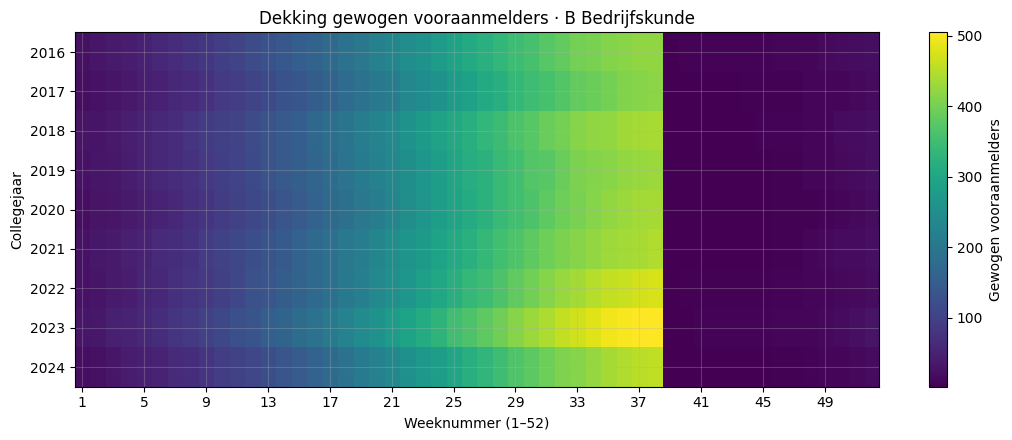

In [6]:
heat = (
    data_cumulative[data_cumulative["Croho groepeernaam"] == PROGRAMMA]
    .pivot_table(index="Collegejaar", columns="Weeknummer",
                 values="Gewogen vooraanmelders", aggfunc="sum")
    .reindex(columns=sorted(data_cumulative["Weeknummer"].unique()))
)

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([str(int(y)) for y in heat.index])
ax.set_xticks(range(0, len(heat.columns), 4))
ax.set_xticklabels([str(int(w)) for w in heat.columns[::4]])
ax.set_xlabel("Weeknummer (1–52)")
ax.set_ylabel("Collegejaar")
ax.set_title(f"Dekking gewogen vooraanmelders · {PROGRAMMA}")
plt.colorbar(im, ax=ax, label="Gewogen vooraanmelders")
plt.tight_layout()
plt.show()


## 6. Conclusie

Met dit rapport heb je in één blik:

- ✅ Verplichte kolommen, jaarbereik, herkomst-waarden, ontbrekende waarden
- ✅ Decimaalintegriteit (volledige scan, geen sample)
- ✅ Continuïteit tussen weken
- ✅ Aansluiting met DUO-realisatie

Bij ⚠️ of ❌ verwijst de docs [`validatie.md`](../docs/validatie.md) naar de oplossing.
Daarna kun je verder met [`02_sarima.ipynb`](02_sarima.ipynb).
